In [1]:
import pandas as pd

file_path = "Reviews.csv"
df = pd.read_csv(file_path, encoding='latin1')

df = df[["Text", "Score"]]
df = df.dropna()
df = df.sample(n=5000, random_state=42)

pd.set_option('display.max_colwidth', None)
print("Successful import")

Successful import


In [2]:
def convert_to_lowercase(text):
    return text.lower()
df["lowercased"] = df["Text"].apply(convert_to_lowercase)

pd.set_option('display.max_colwidth', None)
print(df["lowercased"])

165256                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [3]:
import re

def remove_urls(text):
    return re.sub(r'https\S+|www\S+', '', text)
df["urls_removed"] = df["lowercased"].apply(remove_urls)

pd.set_option('display.max_colwidth', None)
print(df["urls_removed"])

165256                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [4]:
from bs4 import BeautifulSoup

def remove_html_tags(text):
    return BeautifulSoup(text, "html.parser").get_text()
df["html_removed"] = df["urls_removed"].apply(remove_html_tags)

pd.set_option('display.max_colwidth', None)
print(df["html_removed"])

165256                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [61]:
pip install emoji

Note: you may need to restart the kernel to use updated packages.


In [5]:
# Removal of emojis (if any) 
import emoji 
# replace emoji with '' 
def remove_emojis(text): 
    return emoji.replace_emoji(text, replace='') 
df["emojis_removed"] = df["html_removed"].apply(remove_emojis) 
# Display column content without truncation 

pd.set_option('display.max_colwidth', None)  # Set to None for unlimited width 
print(df["emojis_removed"])

165256                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [6]:
# Replace internet slang/chat words 
# Dictionary of slang words and their replacements 
slang_dict = { 
    "tbh": "to be honest", 
    "omg": "oh my god", 
    "lol": "laugh out loud", 
    "idk": "I don't know", 
    "brb": "be right back", 
    "btw": "by the way", 
    "imo": "in my opinion", 
    "smh": "shaking my head", 
    "fyi": "for your information", 
    "np": "no problem",
    "ikr": "I know right", 
    "asap": "as soon as possible", 
    "bff": "best friend forever", 
    "gg": "good game", 
    "hmu": "hit me up", 
    "rofl": "rolling on the floor laughing" 
}
# Function to replace slang words 
def replace_slang(text): 
    # Create a list of escaped slang words 
    escaped_slang_words = []  # Empty list to store escaped slang words
    for word in slang_dict.keys(): 
        escaped_word = re.escape(word)  # Ensure special characters are escaped 
        escaped_slang_words.append(escaped_word)  # Add to list
    # Join the words using '|' 
    slang_pattern = r'\b(' + '|'.join(escaped_slang_words) + r')\b'
    # Define a replacement function 
    def replace_match(match): 
        slang_word = match.group(0)  # Extract matched slang word 
        return slang_dict[slang_word.lower()]  # Replace with full form
    # Use regex to replace slang words with full forms 
    replaced_text = re.sub(slang_pattern, replace_match, text, flags=re.IGNORECASE)
    return replaced_text 

# Apply the function to the column 
df["slangs_replaced"] = df["emojis_removed"].apply(replace_slang)

# Display column content without truncation 
pd.set_option('display.max_colwidth', None)  # Set to None for unlimited width 
print(df["slangs_replaced"])

165256                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [7]:
# Replace Contractions 
contractions_dict = { 
    "wasn't": "was not", 
    "isn't": "is not", 
    "aren't": "are not", 
    "weren't": "were not", 
    "doesn't": "does not", 
    "don't": "do not", 
    "didn't": "did not", 
    "can't": "cannot", 
    "couldn't": "could not", 
    "shouldn't": "should not", 
    "wouldn't": "would not", 
    "won't": "will not", 
    "haven't": "have not", 
    "hasn't": "has not", 
    "hadn't": "had not", 
    "i'm": "i am", 
    "you're": "you are", 
    "he's": "he is", 
    "she's": "she is", 
    "it's": "it is", 
    "we're": "we are", 
    "they're": "they are", 
    "i've": "i have", 
    "you've": "you have", 
    "we've": "we have", 
    "they've": "they have", 
    "i'd": "i would", 
    "you'd": "you would", 
    "he'd": "he would", 
    "she'd": "she would", 
    "we'd": "we would", 
    "they'd": "they would", 
    "i'll": "i will",
    "you'll": "you will", 
    "he'll": "he will", 
    "she'll": "she will", 
    "we'll": "we will", 
    "they'll": "they will", 
    "let's": "let us", 
    "that's": "that is", 
    "who's": "who is", 
    "what's": "what is", 
    "where's": "where is", 
    "when's": "when is", 
    "why's": "why is" 
}

# Build the regex pattern for contractions 
escaped_contractions = []  # List to store escaped contractions

for contraction in contractions_dict.keys(): 
    escaped_contraction = re.escape(contraction)  # Escape special characters (e.g., apostrophes)
    escaped_contractions.append(escaped_contraction)  # Add to list

# Join the escaped contractions with '|' 
joined_contractions = "|".join(escaped_contractions) 

# Create a regex pattern with word boundaries (\b) 
contractions_pattern = r'\b(' + joined_contractions + r')\b' 

# Compile the regex 
compiled_pattern = re.compile(contractions_pattern, flags=re.IGNORECASE)

# Define a function to replace contractions 
def replace_contractions(text): 
    # Function to handle each match found
    def replace_match(match): 
        matched_word = match.group(0)  # Extract matched contraction 
        lower_matched_word = matched_word.lower()  # Convert to lowercase
        expanded_form = contractions_dict[lower_matched_word]  #Get full form from dictionary
        return expanded_form #Return the expanded form
    
    #Apply regex substitution
    expanded_text = compiled_pattern.sub(replace_match, text)

    return expanded_text #Return modified text

# Apply the function to a DataFrame column 
df["contractions_replaced"] = df["slangs_replaced"].apply(replace_contractions)

# Display column content without truncation 
pd.set_option('display.max_colwidth', None)  # Set to None for unlimited width 
print(df["contractions_replaced"])

165256                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [8]:
# Remove punctuations and special characters 
import string

# Function to remove punctuation 
def remove_punctuation(text): 
    return text.translate(str.maketrans('', '', string.punctuation))

# Apply the function to the column 
df["punctuations_removed"] = df["contractions_replaced"].apply(remove_punctuation)

# Display column content without truncation 
pd.set_option('display.max_colwidth', None)  # Set to None for unlimited width 
print(df["punctuations_removed"])

165256                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [9]:
# Remove numbers 
def remove_numbers(text): 
    return re.sub(r'\d+', '', text)  # Removes all numeric characters

# Apply the function to the column 
df["numbers_removed"] = df["punctuations_removed"].apply(remove_numbers)

# Display column content without truncation 
pd.set_option('display.max_colwidth', None)  # Set to None for unlimited width 
print(df["numbers_removed"])

165256                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [10]:
# Remove stopwords 
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already downloaded 
nltk.download('stopwords')

# Define stopwords list 
stop_words = set(stopwords.words('english'))

# Function to remove stopwords 
def remove_stopwords(text):
    words = text.split()  # Split text into words 
    filtered_words = []  # Create an empty list to store words after stopword removal

    for word in words:  # Loop through each word in the list of words
        lower_word = word.lower() #Convert the word to lowercase for uniform comparison
        if lower_word not in stop_words:  # Check if the lowercase word is NOT in the stopwords list
            filtered_words.append(word)  # If it's not a stopword, add it to the filtered list
    return " ".join(filtered_words)  # Join words back into a sentence

# Apply the function to the column 
df["stopwords_removed"] = df["numbers_removed"].apply(remove_stopwords)

# Display column content without truncation 
pd.set_option('display.max_colwidth', None)  # Set to None for unlimited width 
print(df["stopwords_removed"])

165256                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     tried couple brands glutenfree sandwich cookies best bunch crunchy true texture real cookies glutenfree might think filling makes bit sweet means satisfied sweet tooth sooner chocolate version glutino good true chocolatey taste something glutenfree brands
231465       

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kamin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
# Stemming - reduces words to their base root by chopping off suffixes 
from nltk.stem import PorterStemmer

# Initialize the stemmer 
stemmer = PorterStemmer() 

# Function to apply stemming 
def stem_text(text):
    if not isinstance(text, str):
        return ""
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]  # Apply stemming
    return " ".join(stemmed_words)

# Apply the function 
df["stemmed_words"] = df["stopwords_removed"].apply(stem_text)

# Display column content without truncation 
pd.set_option('display.max_colwidth', None)  # Set to None for unlimited width 
print(df["stemmed_words"])

165256                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                tri coupl brand glutenfre sandwich cooki best bunch crunchi true textur real cooki glutenfre might think fill make bit sweet mean satisfi sweet tooth sooner chocol version glutino good true chocolatey tast someth glutenfre brand
231465                                                                                                                       

In [12]:
import nltk

# Download the required resources 
nltk.download('wordnet') # For lemmatization                     
nltk.download('omw-1.4') # WordNet lexical database                    
nltk.download('averaged_perceptron_tagger_eng')  # For POS tagging 
nltk.download('punkt_tab') # For tokenization 

# Lemmatization - reduces words to their base dictionary form (lemma)
from nltk.stem import WordNetLemmatizer 
from nltk.corpus import wordnet 
from nltk.tokenize import word_tokenize 
from nltk import pos_tag

# Initialize the lemmatizer 
lemmatizer = WordNetLemmatizer()

# Function to map NLTK POS tags to WordNet POS tags 
def get_wordnet_pos(nltk_tag):
    if nltk_tag.startswith('J'):  # Adjective
         return wordnet.ADJ
    elif nltk_tag.startswith('V'):  # Verb 
        return wordnet.VERB
    elif nltk_tag.startswith('N'): #Noun
        return wordnet.NOUN
    elif nltk_tag.startswith('R'): #Adverb
        return wordnet.ADV
    else:
        return wordnet.NOUN #Default to noun

#Function to lemmatize text with POS tagging
def lemmatize_text(text):
    if not isinstance(text,str): #Ensure input is string
        return ""
    words = word_tokenize(text) #Tokenize text into words
    pos_tags = pos_tag(words) #get POS tags

    #Lemmatize each word with its correct POS tag
    lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags]

    return " ".join(lemmatized_words)  # Join words back into a sentence

# Apply the function to the column 
df["lemmatized"] = df["stopwords_removed"].apply(lemmatize_text)

# Display column content without truncation 
pd.set_option('display.max_colwidth', None)  # Set to None for unlimited width 
print(df["lemmatized"])

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\kamin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\kamin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\kamin\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kamin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


165256                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 tried couple brand glutenfree sandwich cooky best bunch crunchy true texture real cooky glutenfree might think fill make bit sweet mean satisfied sweet tooth sooner chocolate version glutino good true chocolatey taste something glutenfree brand
231465                                                      

In [13]:
df.to_csv("Processed_Reviews.csv", index=False)

In [14]:
df = pd.read_csv("Processed_Reviews.csv",encoding="ISO-8859-1")

print(df.columns)

Index(['Text', 'Score', 'lowercased', 'urls_removed', 'html_removed',
       'emojis_removed', 'slangs_replaced', 'contractions_replaced',
       'punctuations_removed', 'numbers_removed', 'stopwords_removed',
       'stemmed_words', 'lemmatized'],
      dtype='object')


In [15]:
df = df.dropna(subset=["lemmatized"])

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["lemmatized"])

# convert score to sentiment
y = df["Score"].apply(lambda x: 1 if x >= 4 else 0)

In [17]:
from sklearn.naive_bayes import MultinomialNB 
from sklearn.svm import SVC 
from sklearn.model_selection import train_test_split 

# Split data into train & test sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [18]:
# Naive Bayes 
nb_clf = MultinomialNB().fit(X_train, y_train)

In [19]:
# Performance metrics comparison 
from sklearn.metrics import classification_report, confusion_matrix 
from sklearn.metrics import accuracy_score  # Importing accuracy_score 
 
# Naive Bayes 
nb_predicted = nb_clf.predict(X_test) 
nb_report = classification_report(y_test, nb_predicted) 
# Calculate error rate for Naive Bayes 
nb_error_rate = 1 - accuracy_score(y_test, nb_predicted) 
nb_cm = confusion_matrix(y_test, nb_predicted)

In [20]:
nb_cm

array([[  2, 257],
       [  0, 991]])

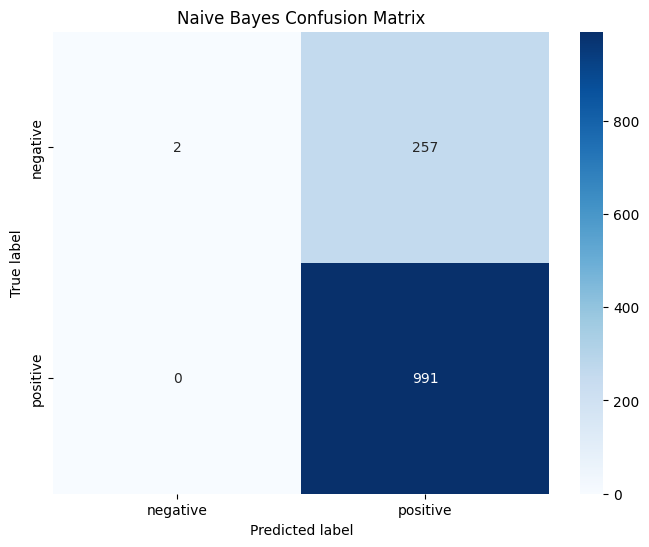

Naive Bayes Classifier Report:
              precision    recall  f1-score   support

           0       1.00      0.01      0.02       259
           1       0.79      1.00      0.89       991

    accuracy                           0.79      1250
   macro avg       0.90      0.50      0.45      1250
weighted avg       0.84      0.79      0.70      1250


Naive Bayes Error Rate: 0.21


In [21]:
import matplotlib.pyplot as plt 
import seaborn as sns 
 
# Function to plot confusion matrix 
def plot_confusion_matrix(cm, classes, title='Confusion matrix', cmap=plt.cm.Blues): 
    plt.figure(figsize=(8, 6)) 
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, 
yticklabels=classes) 
    plt.title(title) 
    plt.xlabel('Predicted label') 
    plt.ylabel('True label') 
    plt.show() 
 
# Plot confusion matrix for Naive Bayes 
plot_confusion_matrix(nb_cm, classes=['negative', 'positive'], title='Naive Bayes Confusion Matrix') 
 
print("Naive Bayes Classifier Report:") 
print(nb_report) 
print(f"\nNaive Bayes Error Rate: {nb_error_rate:.2f}") 

In [24]:
pip install textblob vaderSentiment

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---

  Using cached textblob-0.20.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata (572 bytes)
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   -

In [25]:
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

analyzer = SentimentIntensityAnalyzer()

#TextBlob prediction
def textblob_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    return 1 if polarity > 0 else 0

#VADER prediction
def vader_sentiment(text):
    score = analyzer.polarity_scores(str(text))
    return 1 if score['compound'] >= 0 else 0

#apply to dataset
df["tb_pred"] = df["Text"].apply(textblob_sentiment)
df["vader_pred"] = df["Text"].apply(vader_sentiment)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\kamin\AppData\Roaming\nltk_data...


In [26]:
test_indices = X_test.indices if hasattr(X_test, 'indices') else y_test.index

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(X, y, df.index, random_state=42)

tb_test = df.loc[idx_test, "tb_pred"]
vader_test = df.loc[idx_test, "vader_pred"]

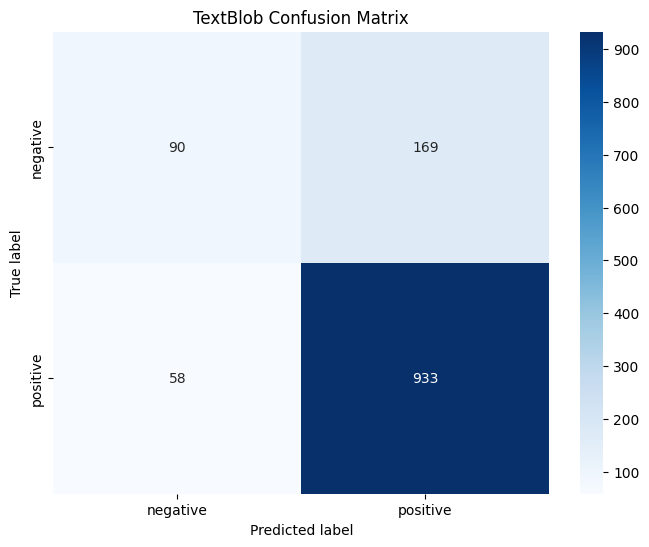

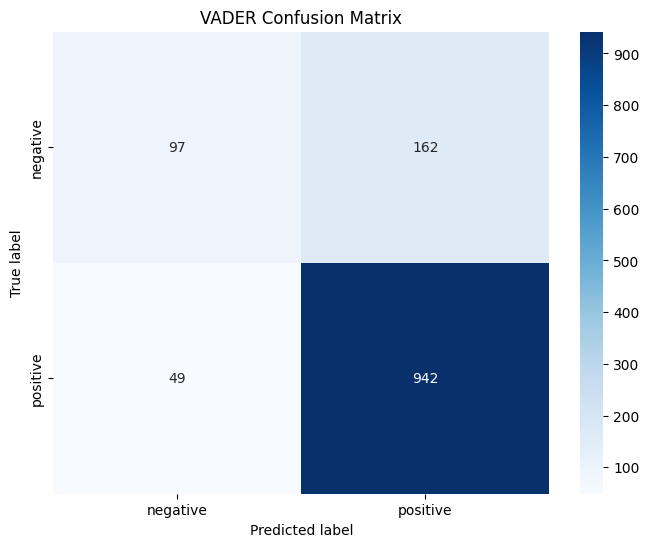

TextBlob Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.35      0.44       259
           1       0.85      0.94      0.89       991

    accuracy                           0.82      1250
   macro avg       0.73      0.64      0.67      1250
weighted avg       0.80      0.82      0.80      1250

TextBlob Error Rate: 0.18

VADER Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.37      0.48       259
           1       0.85      0.95      0.90       991

    accuracy                           0.83      1250
   macro avg       0.76      0.66      0.69      1250
weighted avg       0.81      0.83      0.81      1250

VADER Error Rate: 0.17


In [27]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

tb_report = classification_report(y_test, tb_test)
tb_error = 1 - accuracy_score(y_test, tb_test)
tb_cm = confusion_matrix(y_test, tb_test)

vader_report = classification_report(y_test, vader_test)
vader_error = 1 - accuracy_score(y_test, vader_test)
vader_cm = confusion_matrix(y_test, vader_test)

plot_confusion_matrix(tb_cm, classes=['negative', 'positive'], title='TextBlob Confusion Matrix')
plot_confusion_matrix(vader_cm, classes=['negative', 'positive'], title='VADER Confusion Matrix')

print("TextBlob Classification Report:")
print(tb_report)
print(f"TextBlob Error Rate: {tb_error:.2f}")

print("\nVADER Classification Report:")
print(vader_report)
print(f"VADER Error Rate: {vader_error:.2f}")

Conclusion:
Student's Name:
Syasya Masturina BT Ibrahim (IS01083881)
Kaminy Varma (IS01083876)

For this lab assignment, 2 Lexicon-based approaches and 1 machine-learning(Naive Nayes) approach was applied. The results are as below:
- VADER achieved the highest accuracy (83%) and lowest error rate (17%), as it can handle the nuances of informal language that is typically present online, which is most suitable for the sentiment analysis of the reviews.
- TextBlob performed slightly lower than VADER(error rate of 0.18) but better than Naive Bayes.
- Naive Bayes had the lowest performance and struggled to classify negative reviews correctly, as the dataset had a class imbalance which the Bayesian model is quite sensitive to, and tends to favor the majority class(in this case, the positive class).